# LSTM-SVR-L model

In [20]:
import pandas as pd
import numpy as np

In [21]:
df = pd.read_csv('../data/df_with_2regimes.csv')

# lag 1,2 andd 3 of realized volatility
df['rv_lag1'] = df['realized_volatility'].shift(1)
df['rv_lag2'] = df['realized_volatility'].shift(2)
df['rv_lag3'] = df['realized_volatility'].shift(3)

# rolling mean of realized volatility over the past 30 days
df['rv_rolling_mean_30'] = df['realized_volatility'].rolling(window=30).mean() 

# drop rows with NaN values (due to lag and rolling mean)
df = df.dropna().reset_index(drop=True)
df.head(30)
df.info()
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3489 entries, 0 to 3488
Data columns (total 41 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        3489 non-null   object 
 1   log_return                                  3489 non-null   float64
 2   realized_variance                           3489 non-null   float64
 3   realized_volatility                         3489 non-null   float64
 4   gtrend_pct_change                           3489 non-null   float64
 5   blockchain_diff_log_n_transactions          3489 non-null   float64
 6   blockchain_diff_log_transaction_fee_usd     3489 non-null   float64
 7   blockchain_diff_log_n_unique_addresses      3489 non-null   float64
 8   blockchain_diff_log_transaction_volume_usd  3489 non-null   float64
 9   log_volume                                  3489 non-null   float64
 10  target      

In [22]:
lstm_features = ["gtrend_pct_change",
    "blockchain_diff_log_n_transactions",
    "blockchain_diff_log_transaction_fee_usd",
    "blockchain_diff_log_n_unique_addresses",
    "blockchain_diff_log_transaction_volume_usd",
    "log_volume",
    "gold_close_ret",
    "silver_close_ret",
    "brent_close_ret",
    "dji_close_ret",
    "spx_close_ret",
    "rut_close_ret",
    "nasdaq_close_ret",
    "usdcny_close_ret",
    "usdeur_close_ret",
    "gold_volume_chg",
    "silver_volume_chg",
    "brent_volume_chg",
    "dji_volume_chg",
    "spx_volume_chg",
    "rut_volume_chg",
    "nasdaq_volume_chg",
    "vix_close_chg",
    "hash-rate_chg",
    "difficulty_chg",
    "median-confirmation-time_chg",
    "blockchain_log_mempool_count_chg"
    ]

svr_features = ["rv_lag1", "rv_lag2", "rv_lag3", "rv_rolling_mean_30"]

In [23]:
train_size = int(len(df) * 0.7)
eval_size = int(len(df) * 0.15)
train_df = df.iloc[:train_size]

eval_df = df.iloc[train_size:train_size + eval_size]
test_df = df.iloc[train_size + eval_size:]
print(f"Train set: {len(train_df)} rows")
print(f"Evaluation set: {len(eval_df)} rows")
print(f"Test set: {len(test_df)} rows")


X_train_lstm = train_df[lstm_features]
X_eval_lstm  = eval_df[lstm_features]
X_test_lstm  = test_df[lstm_features]

y_train_regime = train_df["regime_id"].shift(-1)  # shift by 1 to predict next day's regime
y_eval_regime  = eval_df["regime_id"]
y_test_regime  = test_df["regime_id"]

Train set: 2442 rows
Evaluation set: 523 rows
Test set: 524 rows


## Weighted LSTM Objective

Each observation is assigned a weight

$$
w_t = (1-\lambda)\frac{T}{\sum_{s=1}^{T} \mathbf{1}\{g_t = g_s\}}
+
\lambda
\frac{\sum_{s=1}^{T} \mathbf{1}\{g_s \ne g_{s-1}\}}
{\sum_{s=1}^{T} \mathbf{1}\{g_t = g_s\}\mathbf{1}\{g_s \ne g_{s-1}\}}
$$

where

- $T$ is the number of observations  
- $g_t$ is the regime label at time $t$  
- $\mathbf{1}\{\cdot\}$ is the indicator function  
- $\lambda \in [0,1]$ controls the emphasis on regime switching observations.

The LSTM is trained using a **weighted categorical cross-entropy loss**

$$
\mathcal{L} =
-\frac{1}{T}
\sum_{t=1}^{T}
w_t
\sum_{k=1}^{K}
y_{t,k}\log(\hat{y}_{t,k})
$$

where

- $K$ = number of regimes  
- $y_{t,k}$ = true indicator of regime $k$ at time $t$  
- $\hat{y}_{t,k}$ = predicted probability from the LSTM softmax layer  
- $w_t$ = observation weight.

In [24]:
def compute_weights(regimes, lam=0.5, eps=1e-12):
    regimes = np.asarray(regimes).astype(int)
    T = len(regimes)

    switch_flag = np.zeros(T, dtype=int)
    switch_flag[1:] = (regimes[1:] != regimes[:-1]).astype(int)

    unique_regimes = np.unique(regimes)

    class_count = {g: np.sum(regimes == g) for g in unique_regimes}
    switch_count = {
        g: np.sum((regimes == g) & (switch_flag == 1))
        for g in unique_regimes
    }
    total_switches = np.sum(switch_flag)

    weights = np.zeros(T, dtype=float)

    for t in range(T):
        g = regimes[t]

        imbalance_term = T / (class_count[g] + eps)

        if total_switches > 0 and switch_count[g] > 0:
            switch_term = total_switches / (switch_count[g] + eps)
        else:
            switch_term = 0.0 

        weights[t] = (1 - lam) * imbalance_term + lam * switch_term 

    # normalize weights for stability
    weights = weights / np.mean(weights)

    return weights, switch_flag

In [25]:
# use this for evaluation and testing
def create_rolling_scaled_sequences_range(
    df, feature_cols, target_col, lookback, scale_window, start_idx, end_idx, date_col=None
):
    X, y, dates = [], [], []

    first_valid_idx = max(start_idx, lookback, scale_window)

    for t in range(first_valid_idx, end_idx - 1):

        hist_window = df[feature_cols].iloc[t - scale_window:t]
        seq_window = df[feature_cols].iloc[t - lookback:t]

        target = df[target_col].iloc[t + 1]

        if hist_window.isnull().any().any():
            continue
        if seq_window.isnull().any().any():
            continue
        if pd.isna(target):
            continue

        scaler = StandardScaler()
        scaler.fit(hist_window)

        seq_scaled = scaler.transform(seq_window)

        X.append(seq_scaled)
        y.append(target)

        if date_col is not None:
            dates.append(df[date_col].iloc[t + 1])
        else:
            dates.append(t + 1)

    return np.array(X), np.array(y), dates

In [26]:
# use this for training
def create_rolling_scaled_sequences_range_weights(
    df, feature_cols, target_col, lookback, scale_window,
    start_idx, end_idx, weights_full, date_col=None
):
    X, y, dates, target_idx, w = [], [], [], [], []

    first_valid_idx = max(start_idx, lookback, scale_window)

    for t in range(first_valid_idx, end_idx - 1):
        hist_window = df[feature_cols].iloc[t - scale_window:t]
        seq_window = df[feature_cols].iloc[t - lookback:t]
        target = df[target_col].iloc[t + 1]

        # weight aligned with target at t+1
        weight = weights_full[t + 1]

        if hist_window.isnull().any().any():
            continue
        if seq_window.isnull().any().any():
            continue
        if pd.isna(target):
            continue
        if pd.isna(weight):
            continue

        scaler = StandardScaler()
        scaler.fit(hist_window)
        seq_scaled = scaler.transform(seq_window)

        X.append(seq_scaled)
        y.append(target)
        w.append(weight)
        target_idx.append(t + 1)

        if date_col is not None:
            dates.append(df[date_col].iloc[t + 1])
        else:
            dates.append(t + 1)

    return np.array(X), np.array(y), dates, np.array(w), np.array(target_idx)

def scale_rolling(df_hist, feature_cols, lookback, scale_window=730):

    scaler_hist = df_hist[feature_cols].iloc[-min(scale_window, len(df_hist)):].copy()

    scaler = StandardScaler()
    scaler.fit(scaler_hist)

    seq_raw = df_hist[feature_cols].iloc[-lookback:].copy()

    seq_scaled = scaler.transform(seq_raw)

    return seq_scaled, scaler

def build_lstm_model(lookback, n_features, n_regimes=2, units=64, dropout=0.2, optimizer="adam"):
    model = Sequential([
        LSTM(units, input_shape=(lookback, n_features)),
        Dropout(dropout),
        Dense(32, activation="relu"),
        Dense(n_regimes, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [27]:
def rolling_regime_forecast(
    df_full,
    lstm_model,
    feature_cols,
    lookback,
    start_idx,
    end_idx,
    scale_window=730,
    date_col="date",
    target_col="regime_id"
):

    results = []

    for t in range(start_idx - 1, end_idx - 1):

        df_hist = df_full.iloc[:t+1].copy()

        if len(df_hist) < lookback:
            continue

        try:
            seq_scaled, _ = scale_rolling(
                df_hist,
                feature_cols=feature_cols,
                lookback=lookback,
                scale_window=scale_window
            )
        except Exception:
            continue

        X_input = np.expand_dims(seq_scaled, axis=0)

        pred_probs = lstm_model.predict(X_input, verbose=0)
        pred_regime = int(np.argmax(pred_probs))

        results.append({
            "date": df_full.iloc[t][date_col],
            "pred_regime": pred_regime,
            "pred_prob_0": pred_probs[0,0],
            "pred_prob_1": pred_probs[0,1]
        })

    return pd.DataFrame(results)

# SVR-Linear

In [28]:
def fit_svr_safe(X_train, y_train, C=1.0, kernel="linear", epsilon=1e-4, min_obs=250):
    if len(X_train) < min_obs:
        return None

    try:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR(kernel=kernel, C=C, epsilon=epsilon))
        ])
        model.fit(X_train, y_train)
        return model
    except Exception:
        return None


def one_step_svr_forecast(fitted_svr, x_next):
    
    if fitted_svr is None:
        return np.nan

    try:
        x_next = np.asarray(x_next).reshape(1, -1)
        pred = fitted_svr.predict(x_next)[0]
        return float(pred)
    except Exception:
        return np.nan

In [29]:
def rolling_lstm_svr_linear_eval(
    df_full,
    regime_forecast_df,
    start_idx,
    end_idx,
    x_feature_cols,
    realized_var_col="realized_variance",
    date_col="date",
    rolling_window=730,
    C=1.0,
    epsilon=1e-4,
    min_obs=200,
    use_prob_1_only=True,
    kernel="linear"
):
    results = []

    df = df_full.copy()
    regime_df = regime_forecast_df.copy()

    merge_cols = [date_col, "pred_regime", "pred_prob_0", "pred_prob_1"]
    df = df.merge(regime_df[merge_cols], on=date_col, how="left")

    # target for next day
    df["rv_lead1"] = df[realized_var_col].shift(-1)

    prob_cols = ["pred_prob_1"] if use_prob_1_only else ["pred_prob_0", "pred_prob_1"]
    feature_cols = x_feature_cols + prob_cols

    for t in range(start_idx - 1, end_idx - 1):
        current_row = df.iloc[t]
        next_row = df.iloc[t + 1]

        current_date = current_row[date_col]
        next_date = next_row[date_col]

        window_df = df.iloc[max(0, t - rolling_window + 1): t + 1].copy()

        needed_cols = feature_cols + ["rv_lead1"]
        train_df = window_df[needed_cols].dropna()

        if len(train_df) < min_obs:
            results.append({
                "date": next_date,
                "forecast_origin_date": current_date,
                "actual_var": next_row[realized_var_col],
                "pred_regime": current_row.get("pred_regime", np.nan),
                "pred_prob_0": current_row.get("pred_prob_0", np.nan),
                "pred_prob_1": current_row.get("pred_prob_1", np.nan),
                "var_svr": np.nan
            })
            continue

        X_train = train_df[feature_cols].values
        y_train = train_df["rv_lead1"].values

        model = fit_svr_safe(
            X_train=X_train,
            y_train=y_train,
            kernel=kernel,
            C=C,
            epsilon=epsilon,
            min_obs=min_obs
        )

        x_next = current_row[feature_cols]

        if x_next.isna().any():
            pred = np.nan
        else:
            pred = one_step_svr_forecast(model, x_next.values)

        results.append({
            "date": next_date,
            "forecast_origin_date": current_date,
            "actual_var": next_row[realized_var_col],
            "pred_regime": current_row.get("pred_regime", np.nan),
            "pred_prob_0": current_row.get("pred_prob_0", np.nan),
            "pred_prob_1": current_row.get("pred_prob_1", np.nan),
            "var_svr": pred
        })

    return pd.DataFrame(results)

#### metrics

In [30]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask]) ** 2))


def qlike(y_true, y_pred, eps=1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (y_true > 0) & (y_pred > 0)
    if mask.sum() == 0:
        return np.nan

    yt = y_true[mask]
    yp = y_pred[mask]

    return np.mean(np.log(yp + eps) + yt / (yp + eps))


In [31]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import backend as K
import tensorflow as tf
import gc
from itertools import product 
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [32]:
train_start_idx = 0
train_end_idx = train_size

eval_start_idx = train_size
eval_end_idx = train_size + eval_size

test_start_idx = eval_end_idx
test_end_idx = len(df)

In [38]:
lstm_grid = {
    "lookback": [20, 30, 60],
    "units": [32, 64],
    "dropout": [0.0, 0.1, 0.2],
    "batch_size": [32,64]
}

lstm_param_grid = []
for lb, units, drop, bs in product(
    lstm_grid["lookback"],
    lstm_grid["units"],
    lstm_grid["dropout"],
    lstm_grid["batch_size"]
):
    lstm_param_grid.append({
        "lookback": lb,
        "units": units,
        "dropout": drop,
        "batch_size": bs
    })


svr_grid = {
    "kernel": ["linear"],
    "C": [0.1, 1.0, 10.0],
    "epsilon": [1e-4, 1e-3, 1e-2]
}

svr_param_grid = []
for kernel, C, epsilon in product(
    svr_grid["kernel"],
    svr_grid["C"],
    svr_grid["epsilon"]
):
    svr_param_grid.append({
        "kernel": kernel,
        "C": C,
        "epsilon": epsilon
    })

print(f"Total LSTM configs: {len(lstm_param_grid)}")
print(f"Total SVR configs: {len(svr_param_grid)}")

Total LSTM configs: 36
Total SVR configs: 9


#### Tune LSTM on fixed SVR

In [39]:
fixed_svr_params = {
    "kernel": "linear",
    "C": 1.0,
    "epsilon": 1e-4
}

lstm_results = []

for i, params in enumerate(lstm_param_grid, 1):
    lb = params["lookback"]
    units = params["units"]
    drop = params["dropout"]
    bs = params["batch_size"]

    print(f"\n[{i}/{len(lstm_param_grid)}] Testing LSTM: {params}")

    try:
        K.clear_session()
        tf.keras.backend.clear_session()
        gc.collect()

        lookback = lb

        train_weights_full, train_switch_flags = compute_weights(
            train_df["regime_id"].values, lam=0.5
        )

        X_train_lstm, y_train_regime, train_dates, w_train, train_idx = (
            create_rolling_scaled_sequences_range_weights(
                df=train_df,
                feature_cols=lstm_features,
                target_col="regime_id",
                lookback=lookback,
                scale_window=730,
                start_idx=0,
                end_idx=len(train_df),
                weights_full=train_weights_full,
                date_col="date"
            )
        )

        w_train = w_train.astype(np.float32)

        X_eval_lstm, y_eval_regime, eval_dates = create_rolling_scaled_sequences_range(
            df=df,
            feature_cols=lstm_features,
            target_col="regime_id",
            lookback=lookback,
            scale_window=730,
            start_idx=eval_start_idx,
            end_idx=eval_end_idx,
            date_col="date"
        )

        if len(X_train_lstm) == 0 or len(X_eval_lstm) == 0:
            print("Skipping: no sequences produced.")
            lstm_results.append({
                **params,
                "eval_rmse": np.nan,
                "eval_qlike": np.nan,
                "n_eval_forecasts": 0,
                "error": "no sequences produced"
            })
            continue

        y_train_cat = to_categorical(y_train_regime, num_classes=2)
        y_eval_cat = to_categorical(y_eval_regime, num_classes=2)

        model = build_lstm_model(
            lookback=lookback,
            n_features=len(lstm_features),
            n_regimes=2,
            units=units,
            dropout=drop,
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
        )

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        )

        model.fit(
            X_train_lstm,
            y_train_cat,
            sample_weight=w_train,
            validation_data=(X_eval_lstm, y_eval_cat),
            epochs=100,
            batch_size=bs,
            callbacks=[early_stop],
            verbose=0
        )

        eval_regime_roll = rolling_regime_forecast(
            df_full=df,
            lstm_model=model,
            feature_cols=lstm_features,
            lookback=lookback,
            start_idx=eval_start_idx,
            end_idx=eval_end_idx,
            scale_window=730,
            date_col="date",
            target_col="regime_id"
        )

        eval_stage2 = rolling_lstm_svr_linear_eval(
            df_full=df,
            regime_forecast_df=eval_regime_roll,
            start_idx=eval_start_idx,
            end_idx=eval_end_idx,
            x_feature_cols=svr_features,
            realized_var_col="realized_variance",
            date_col="date",
            rolling_window=730,
            kernel=fixed_svr_params["kernel"],
            C=fixed_svr_params["C"],
            epsilon=fixed_svr_params["epsilon"],
            min_obs=200,
            use_prob_1_only=True
        )

        eval_rmse = rmse(eval_stage2["actual_var"], eval_stage2["var_svr"])
        eval_qlike = qlike(eval_stage2["actual_var"], eval_stage2["var_svr"])
        n_eval_forecasts = eval_stage2["var_svr"].notna().sum()

        lstm_results.append({
            **params,
            "eval_rmse": eval_rmse,
            "eval_qlike": eval_qlike,
            "n_eval_forecasts": n_eval_forecasts
        })

    except Exception as e:
        print(f"Error for params {params}: {e}")
        lstm_results.append({
            **params,
            "eval_rmse": np.nan,
            "eval_qlike": np.nan,
            "n_eval_forecasts": 0,
            "error": str(e)
        })

lstm_results_df = pd.DataFrame(lstm_results).sort_values("eval_qlike")
print(lstm_results_df.head())


[1/36] Testing LSTM: {'lookback': 20, 'units': 32, 'dropout': 0.0, 'batch_size': 32}

[2/36] Testing LSTM: {'lookback': 20, 'units': 32, 'dropout': 0.0, 'batch_size': 64}

[3/36] Testing LSTM: {'lookback': 20, 'units': 32, 'dropout': 0.1, 'batch_size': 32}

[4/36] Testing LSTM: {'lookback': 20, 'units': 32, 'dropout': 0.1, 'batch_size': 64}

[5/36] Testing LSTM: {'lookback': 20, 'units': 32, 'dropout': 0.2, 'batch_size': 32}

[6/36] Testing LSTM: {'lookback': 20, 'units': 32, 'dropout': 0.2, 'batch_size': 64}

[7/36] Testing LSTM: {'lookback': 20, 'units': 64, 'dropout': 0.0, 'batch_size': 32}

[8/36] Testing LSTM: {'lookback': 20, 'units': 64, 'dropout': 0.0, 'batch_size': 64}

[9/36] Testing LSTM: {'lookback': 20, 'units': 64, 'dropout': 0.1, 'batch_size': 32}

[10/36] Testing LSTM: {'lookback': 20, 'units': 64, 'dropout': 0.1, 'batch_size': 64}

[11/36] Testing LSTM: {'lookback': 20, 'units': 64, 'dropout': 0.2, 'batch_size': 32}

[12/36] Testing LSTM: {'lookback': 20, 'units': 64,

#### Tune svr on best LSTM parameters

In [41]:
best_lstm_params = lstm_results_df.iloc[0].to_dict()
print(best_lstm_params)

{'lookback': 20.0, 'units': 32.0, 'dropout': 0.1, 'batch_size': 64.0, 'eval_rmse': 0.0009487356590998805, 'eval_qlike': -6.104842292001563, 'n_eval_forecasts': 324.0}


In [42]:
K.clear_session()
tf.keras.backend.clear_session()
gc.collect()

best_lb = int(best_lstm_params["lookback"])
best_units = int(best_lstm_params["units"])
best_drop = float(best_lstm_params["dropout"])
best_bs = int(best_lstm_params["batch_size"])

train_weights_full, train_switch_flags = compute_weights(
    train_df["regime_id"].values, lam=0.5
)

X_train_lstm, y_train_regime, train_dates, w_train, train_idx = (
    create_rolling_scaled_sequences_range_weights(
        df=train_df,
        feature_cols=lstm_features,
        target_col="regime_id",
        lookback=best_lb,
        scale_window=730,
        start_idx=0,
        end_idx=len(train_df),
        weights_full=train_weights_full,
        date_col="date"
    )
)

w_train = w_train.astype(np.float32)
y_train_cat = to_categorical(y_train_regime, num_classes=2)

X_eval_lstm, y_eval_regime, eval_dates = create_rolling_scaled_sequences_range(
    df=df,
    feature_cols=lstm_features,
    target_col="regime_id",
    lookback=best_lb,
    scale_window=730,
    start_idx=eval_start_idx,
    end_idx=eval_end_idx,
    date_col="date"
)

y_eval_cat = to_categorical(y_eval_regime, num_classes=2)

best_lstm_model = build_lstm_model(
    lookback=best_lb,
    n_features=len(lstm_features),
    n_regimes=2,
    units=best_units,
    dropout=best_drop,
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

best_lstm_model.fit(
    X_train_lstm,
    y_train_cat,
    sample_weight=w_train,
    validation_data=(X_eval_lstm, y_eval_cat),
    epochs=100,
    batch_size=best_bs,
    callbacks=[early_stop],
    verbose=0
)

eval_regime_fixed = rolling_regime_forecast(
    df_full=df,
    lstm_model=best_lstm_model,
    feature_cols=lstm_features,
    lookback=best_lb,
    start_idx=eval_start_idx,
    end_idx=eval_end_idx,
    scale_window=730,
    date_col="date",
    target_col="regime_id"
)

In [43]:
svr_results = []

for i, params in enumerate(svr_param_grid, 1):
    kernel = params["kernel"]
    C = params["C"]
    epsilon = params["epsilon"]

    print(f"\n[{i}/{len(svr_param_grid)}] Testing LSTM: {params}")

    try:
        eval_svr = rolling_lstm_svr_linear_eval(
            df_full=df,
            regime_forecast_df=eval_regime_fixed,
            start_idx=eval_start_idx,
            end_idx=eval_end_idx,
            x_feature_cols=svr_features,
            realized_var_col="realized_variance",
            date_col="date",
            rolling_window=730,
            C=C,
            epsilon=epsilon,
            min_obs=200,
            use_prob_1_only=True,
            kernel=kernel
        )

        eval_rmse = rmse(eval_svr["actual_var"], eval_svr["var_svr"])
        eval_qlike = qlike(eval_svr["actual_var"], eval_svr["var_svr"])
        n_eval_forecasts = eval_svr["var_svr"].notna().sum()

        svr_results.append({
            **params,
            "eval_rmse": eval_rmse,
            "eval_qlike": eval_qlike,
            "n_eval_forecasts": n_eval_forecasts
        })

    except Exception as e:
        svr_results.append({
            **params,
            "eval_rmse": np.nan,
            "eval_qlike": np.nan,
            "n_eval_forecasts": 0,
            "error": str(e)
        })

svr_results_df = pd.DataFrame(svr_results).sort_values("eval_qlike")
print(svr_results_df.head())


[1/9] Testing LSTM: {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.0001}

[2/9] Testing LSTM: {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.001}

[3/9] Testing LSTM: {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.01}

[4/9] Testing LSTM: {'kernel': 'linear', 'C': 1.0, 'epsilon': 0.0001}

[5/9] Testing LSTM: {'kernel': 'linear', 'C': 1.0, 'epsilon': 0.001}

[6/9] Testing LSTM: {'kernel': 'linear', 'C': 1.0, 'epsilon': 0.01}

[7/9] Testing LSTM: {'kernel': 'linear', 'C': 10.0, 'epsilon': 0.0001}

[8/9] Testing LSTM: {'kernel': 'linear', 'C': 10.0, 'epsilon': 0.001}

[9/9] Testing LSTM: {'kernel': 'linear', 'C': 10.0, 'epsilon': 0.01}
   kernel     C  epsilon  eval_rmse  eval_qlike  n_eval_forecasts
1  linear   0.1   0.0010   0.001001   -6.139973               324
7  linear  10.0   0.0010   0.001007   -6.094729               324
6  linear  10.0   0.0001   0.000969   -5.981762               324
0  linear   0.1   0.0001   0.000970   -5.961585               324
3  linear   1.0   0.0001   0.000971  

In [44]:
best_svr_params = svr_results_df.iloc[0].to_dict()
print(best_svr_params)

{'kernel': 'linear', 'C': 0.1, 'epsilon': 0.001, 'eval_rmse': 0.0010012123597365871, 'eval_qlike': -6.139973142296183, 'n_eval_forecasts': 324}


### out of sample testing

In [45]:
test_regime_roll = rolling_regime_forecast(
    df_full=df,
    lstm_model=best_lstm_model,
    feature_cols=lstm_features,
    lookback=best_lb,
    start_idx=test_start_idx,
    end_idx=test_end_idx,
    scale_window=730,
    date_col="date",
    target_col="regime_id"
)

test_svr = rolling_lstm_svr_linear_eval(
    df_full=df,
    regime_forecast_df=test_regime_roll,
    start_idx=test_start_idx,
    end_idx=test_end_idx,
    x_feature_cols=svr_features,
    realized_var_col="realized_variance",
    date_col="date",
    rolling_window=730,
    C=float(best_svr_params["C"]),
    epsilon=float(best_svr_params["epsilon"]),
    min_obs=200,
    use_prob_1_only=True,
    kernel=best_svr_params["kernel"]
)

test_rmse = rmse(test_svr["actual_var"], test_svr["var_svr"])
test_qlike = qlike(test_svr["actual_var"], test_svr["var_svr"])

print("Final Test RMSE :", test_rmse)
print("Final Test QLIKE:", test_qlike)

Final Test RMSE : 0.0007311915315432025
Final Test QLIKE: -6.515202034067513


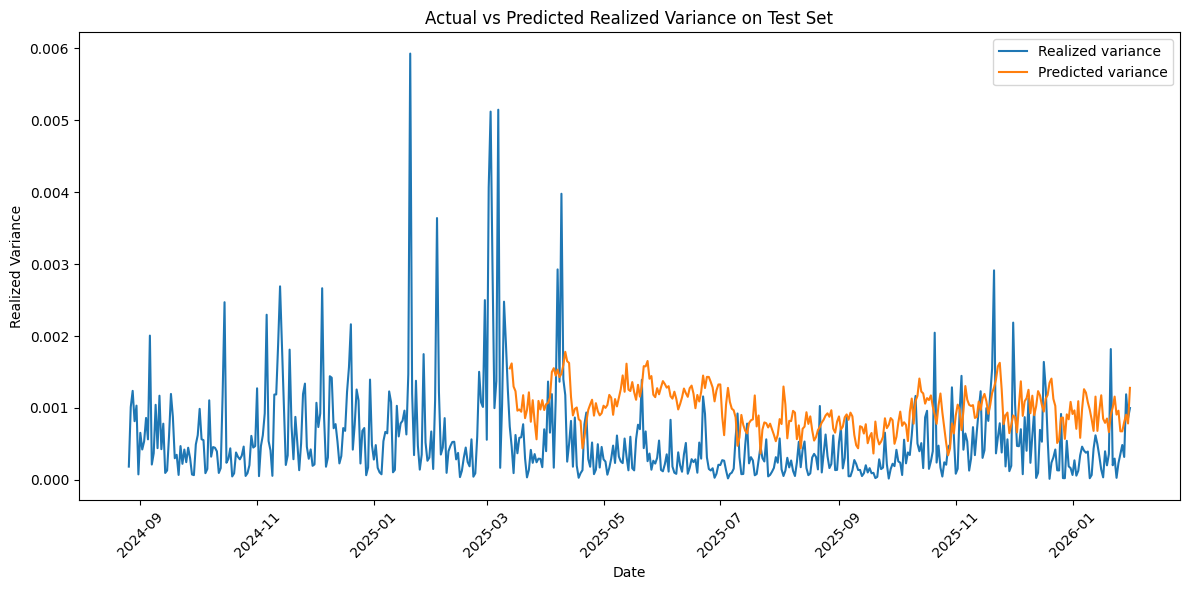

In [51]:
# plot actual vs predicted variance on test set
import matplotlib.pyplot as plt
test_svr['date'] = pd.to_datetime(test_svr['date'])
plt.figure(figsize=(12,6))
plt.plot(test_svr["date"], test_svr["actual_var"], label="Realized variance")
plt.plot(test_svr["date"], test_svr["var_svr"], label="Predicted variance")
plt.title("Actual vs Predicted Realized Variance on Test Set")
plt.xlabel("Date")
plt.ylabel("Realized Variance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [47]:
# save final results and export test predictions
test_svr.to_csv("results/lstm-svr1.csv", index=False)


In [53]:
test_svr.head()

,date,forecast_origin_date,actual_var,pred_regime,pred_prob_0,pred_prob_1,var_svr
0,2024-08-26,2024-08-25,0.000184,0.0,0.559880,0.440120,NaN
1,2024-08-27,2024-08-26,0.001012,0.0,0.539223,0.460777,NaN
2,2024-08-28,2024-08-27,0.001237,0.0,0.535459,0.464542,NaN
3,2024-08-29,2024-08-28,0.000816,0.0,0.568306,0.431694,NaN
4,2024-08-30,2024-08-29,0.001032,0.0,0.553705,0.446295,NaN


In [55]:
print(len(test_df))
print(test_svr["var_svr"].notna().sum())
print(test_svr["var_svr"].isna().sum())

524
325
199


In [ ]:
print(df.loc[:end_idx, ["date", "pred_prob_1"]].head(210))
print(df.loc[start_idx:end_idx, "pred_prob_1"].isna().sum())

date           0
pred_regime    0
pred_prob_0    0
pred_prob_1    0
dtype: int64